# Convergence per Attack per Algorithm

In [1]:
%load_ext autoreload
import sys
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
import pandas as pd
import seaborn as sns
from pathlib import Path
from fastnanoid import generate
from datetime import datetime
import copy

In [2]:
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
lib_path = project_root / "lib"
sys.path.insert(0, str(lib_path))        
sys.path.insert(0, str(project_root))   

In [3]:
%autoreload 2
from lib.graph_factory import GraphFactory, add_graph_plot
from lib.proj_const_estimator import ProjConstEstimator
from lib.utils import fetch_dataset, get_alphas, rng, seed, save_to_pkl, load_from_pkl
from lib.classifier import ByzClassifier, load_run, save_run
from lib.system import SystemSimulator
from lib.metrics import MetricsCalculator
from lib.config import BASE_CONF, NUM_NODES

In [4]:
# Helper Functions
fmt = lambda sec : f"{sec // 60}m {sec % 60:.2f}s"

def convert(o):
    if isinstance(o, np.generic):
        return o.item()
    raise TypeError(f'{type(o)} not serializable')

def get_graph_args(num_byz_nodes):
    target_pi = rng('dir','graphs').dirichlet(np.full(NUM_NODES,1))
    grap_args = {
        'ws_k': 6,
        'ws_p': 0.1,
        'rand_reg_deg':10,
        'geom_radius':0.23,
        'er_p':min(1.0, 3.0 * np.log(NUM_NODES) / NUM_NODES),
        'MH_target_pi':target_pi,
    }
    if(num_byz_nodes == 5):
        r_ub = {
            'erdos-renyi': 0.1461,
            'random-regular': 0.1195,
            'watts-strogatz': 0.0711,
            'geometric': 0.0625,
            'complete': 0.3438
        }
        return grap_args, r_ub
        
    elif(num_byz_nodes == 9):
        grap_args['geometric'] = 0.4
        
        r_ub = {
            'erdos-renyi': 0.043,
            'random-regular': 0.0,
            'watts-strogatz': 0.0,
            'geometric': 0.0,
            'complete': 0.0799
        }
        return grap_args, r_ub
    else: raise ValueError(f'No graph parameters for b={num_byz_nodes}')

In [5]:
RUN_DIR = os.path.join(Path().resolve(), "default")
config = copy.deepcopy(BASE_CONF)
config['train']['b'] = 5
config['sys']['b'] = config['train']['b'] 
config['train']['clf_model'] = 'xgb'
config['data_heterogeneity'] = 100
config['reg_param'] = 1

target_pi = rng('dir','exp11').dirichlet(np.full(NUM_NODES,1))
b = config['train']['b']
graph_args, r_ub = get_graph_args(b)
config['graph_args'] = graph_args
config['graph_weights'] = 'MH'
config['graph_type']='erdos-renyi'
config['rand_dropout'] = min(r_ub[config['graph_type']], 0.2)

graphs = ['random-regular','watts-strogatz', 'geometric', 'erdos-renyi']
ATKS = ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM']
ALGS = ['RDSGD', 'ORACLE', 'IOS', 'SCC', 'TriMean', 'CooMed']
ALGS_TEST = ['RDSGD', 'ORACLE']
COLORS = dict(zip(ALGS, ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']))

# Fix a test attack
atk = 'gaussian'
RUN_ID=2
local_seed = 333

In [6]:
global_dataset = fetch_dataset('MNIST')
gf = GraphFactory(config['train']['num_nodes'], b)
proj_const_estimator = ProjConstEstimator(config, global_dataset, gf) 
clf = ByzClassifier(config, global_dataset, gf)
sys_sim = SystemSimulator(config, global_dataset, gf)
mc = MetricsCalculator(config, global_dataset, rng('mc','exp11'))

In [7]:
%%time
pkl_file = os.path.join(RUN_DIR,f'{config['graph_type']}_b{config['sys']['b']}_{RUN_ID}_s{local_seed}clf_sim_data.pkl.gz')
if os.path.exists(pkl_file):
    conf = load_run(clf, pkl_file)
    proj_const = conf['proj_const']
else:
    proj_const_estimator.configure(config, seed('proj',local_seed))
    proj_const = proj_const_estimator.estimate()
    clf_sim_data = clf.run_simulations(config, proj_const, seed('clf',local_seed))
    save_run(clf, pkl_file, {'proj_const':proj_const})

Simulating RDSGD @ (beta_C=0.1, gamma_C=0.12)
Building training set. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 69774744824)
Building validation set I. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 45148364284)
Building validation set II. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 2532412796638)
Building test set. Simulating ['label_flip', 'sign_flip', 'gaussian', 'ALIE', 'IPM'] (seed 890654095432)
CPU times: user 37min 23s, sys: 1min 28s, total: 38min 52s
Wall time: 3min 10s


FileNotFoundError: [Errno 2] No such file or directory: '/home/linux/Dissertation/exp2/default/erdos-renyi_b5_2_s333clf_sim_data.pkl.gz'

In [123]:
print(f" {g} graph (b={b}) ".center(56, '='))

==================== ER graph (b=5) ====================


,C_fnr,C_fpr,gamma_C,beta_C
0,0.107824,0.010521,0.016711,0.106


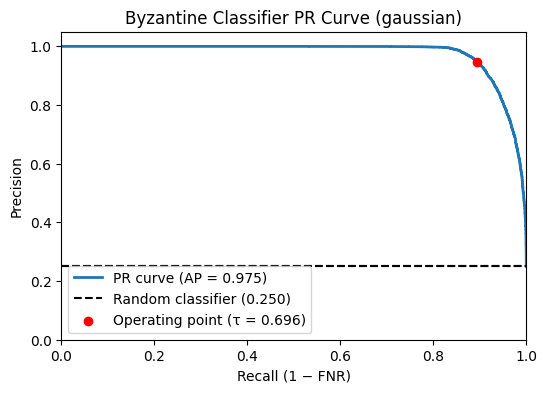

CPU times: user 38.8 s, sys: 66.2 ms, total: 38.9 s
Wall time: 11.9 s


In [8]:
%%time
clf_est, clf_preproc = clf.fit()
clf_op_pt = clf.calc_optimal_op_pt()
clf_metrics = clf.test()

prelim_metrics = dict()
prelim_metrics['proj_const'] = proj_const
prelim_metrics.update(clf_op_pt)
prelim_metrics.update(clf_metrics)
display(pd.DataFrame([prelim_metrics])[['C_fnr','C_fpr', 'gamma_C', 'beta_C']])

fig, ax = plt.subplots(1,1,figsize=(6,4))
clf.plot_pr(ax)
ax.axhline(clf.prevalence, color='k', linestyle='--')
ax.set_title(f'Byzantine Classifier PR Curve ({atk})')
fig.savefig(os.path.join(RUN_DIR,f'{config['graph_type']}_b{config['sys']['b']}_{atk}_{RUN_ID}_byz_clf_pr_curve.png'))
plt.show()

In [9]:
%%time
sim_params = {
    'algorithms': ALGS,
    'atk_type': atk,
    'threat_model': 'T3',
    'seed': local_seed
}
params_C = dict()

# Specifies RDSGD_ORACLE Parameters
params_C['C_fpr'] = clf_metrics['gamma_C']
params_C['C_fnr'] = clf_metrics['beta_C']

# Specifies RDSGD Parameters
params_C['C_tau'] = clf_op_pt['C_tau']

sys_sim.init_simulation(config, proj_const, clf_preproc, clf_est, params_C, seed('sys', local_seed))
df = sys_sim.simulate(sim_params, dropout=config['rand_dropout'])

=========================RDSGD==========================
[k=50] train_loss: [2.073,2.088],test_acc: [0.843,0.852]
[k=100] train_loss: [2.073,2.088],test_acc: [0.850,0.853]
[k=150] train_loss: [2.073,2.088],test_acc: [0.850,0.853]
=========================ORACLE=========================
[k=50] train_loss: [2.073,2.089],test_acc: [0.842,0.850]
[k=100] train_loss: [2.073,2.088],test_acc: [0.848,0.852]
[k=150] train_loss: [2.073,2.088],test_acc: [0.851,0.853]
==========================IOS===========================
[k=50] train_loss: [2.144,15.493],test_acc: [0.145,0.782]
[k=100] train_loss: [2.264,17.078],test_acc: [0.156,0.675]
[k=150] train_loss: [2.426,18.705],test_acc: [0.157,0.590]
==========================SCC===========================
[k=50] train_loss: [2.079,2.091],test_acc: [0.839,0.846]
[k=100] train_loss: [2.083,2.095],test_acc: [0.839,0.844]
[k=150] train_loss: [2.088,2.103],test_acc: [0.836,0.842]
========================TriMean=========================
[k=50] train_loss: [

In [10]:
df.to_csv(os.path.join(RUN_DIR,f'{config['graph_type']}_{atk}_b_{b}_results_dataset_{RUN_ID}.csv'))

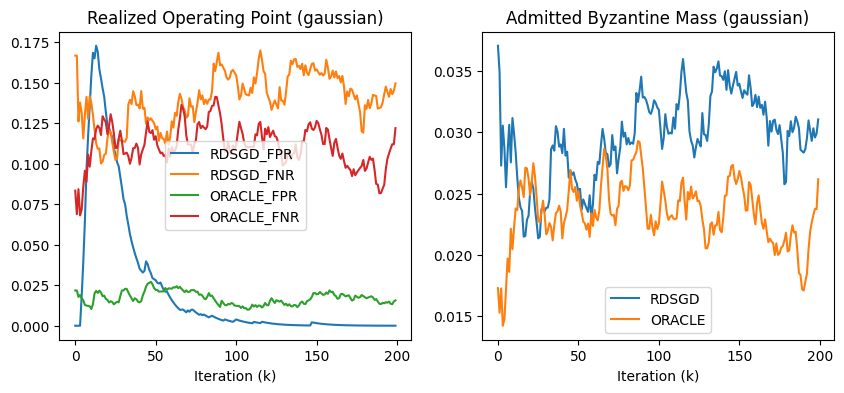

In [11]:
# Plot Realized FPR and FNR 
fig, ax = plt.subplots(1,2,figsize=(10,4))
for idx, alg in enumerate(ALGS_TEST):
    ax[0].plot(df.loc[alg, 'gamma_k'].ewm(com=10, adjust=True).mean(), label=f'{alg}_FPR')
    ax[0].plot(df.loc[alg, 'beta_k'].ewm(com=10, adjust=True).mean(), label=f'{alg}_FNR')
    ax[1].plot(df.loc[alg, 'byz_w_k'].ewm(com=10, adjust=True).mean(), label=alg)
ax[0].set(title=f'Realized Operating Point ({atk})', xlabel='Iteration (k)', ylabel='')
ax[1].set(title=f'Admitted Byzantine Mass ({atk})', xlabel='Iteration (k)', ylabel='')
ax[0].legend()
ax[1].legend()
plt.show()
fig.savefig(os.path.join(RUN_DIR,f'{config['graph_type']}_b{config['sys']['b']}_{atk}_{RUN_ID}_realized_fpr_fnr.png'))

In [12]:
rdsgd_consts = mc(sys_sim.get_sim_config(), sys_sim.models, params_C['C_fpr'], params_C['C_fnr'], proj_const) 
alphas = sys_sim.alphas[0]
beta_realized = df.loc['RDSGD', 'beta_k']
beta_C = clf_metrics['beta_C']

mu = rdsgd_consts['mu']
dB_max = rdsgd_consts['dB_max']

r_ub = (((alphas * mu) / (4*dB_max))-beta_C)/(1-beta_C)
r_ub

np.float64(0.2502350614401971)

In [117]:
g='ER'
atk = 'Y'

metrics_file_path = os.path.join(RUN_DIR, f'metrics_{config['sys']['b']}_{RUN_ID}.csv')
rdsgd_consts = mc(sys_sim.get_sim_config(), sys_sim.models, clf_metrics['gamma_C'], clf_metrics['beta_C'], proj_const)
pi, x_opt, x_pi_opt = rdsgd_consts['pi'], rdsgd_consts['x_opt'], rdsgd_consts['x_pi_opt']
del rdsgd_consts['pi']
del rdsgd_consts['x_opt']
del rdsgd_consts['x_pi_opt']
metrics_payload = rdsgd_consts.copy()
metrics_payload.update({'atk':atk, 'graph':g})

if not os.path.exists(metrics_file_path):
    df_metrics = pd.DataFrame([metrics_payload])
    df_metrics.set_index(['graph','atk'],inplace=True)
else:
    df_metrics = pd.read_csv(metrics_file_path)
    df_metrics.set_index(['graph','atk'],inplace=True)
    
    new_row = pd.DataFrame([metrics_payload]).set_index(['graph', 'atk'])
    if (g, atk) in df_metrics.index:
        df_metrics.loc[(g, atk)] = new_row.loc[(g, atk)]
        # df_metrics = df_metrics.astype(object)
        # df_metrics.loc[(g, atk)] = pd.Series(metrics_payload)
        display(df_metrics)
    else:
        df_metrics = pd.concat([df_metrics, new_row])
        
df_metrics.to_csv(metrics_file_path)

In [138]:
clf_metrics

{'proj_const': np.float64(1.4707910581813861),
 'C_fpr': 0.010520833333333333,
 'C_fnr': 0.10782352941176465,
 'C_tau': 0.6956727504730225,
 'C_auc': 0.9880551966911765,
 'cv_ap': np.float64(0.9701534141674776),
 'cv_params': {'learning_rate': 0.1,
  'max_depth': 5,
  'min_child_weight': 200,
  'reg_lambda': 10.0},
 'prevalence': 0.25,
 'tau': 0.6956727504730225,
 'tn': np.int64(44248),
 'fp': np.int64(752),
 'fn': np.int64(1590),
 'tp': np.int64(13410),
 'op_prec': np.float64(0.9469001553452903),
 'op_rec': np.float64(0.894),
 'beta_C': np.float64(0.106),
 'gamma_C': np.float64(0.01671111111111111),
 'roc_auc': 0.9878250362962963,
 'avg_prec': 0.9751412594083798,
 'graph': 'Y'}

In [118]:
df_tmp = pd.read_csv(metrics_file_path)
df_tmp.set_index(['graph','atk'],inplace=True)
df_tmp

g        s2    lam_pi      nu2  nu2_bound  \
graph          atk                                                           
random-regular sign_flip  0.432757  0.567243  0.750861  0.00345   0.008216   
               gaussian   0.432757  0.567243  0.750861  0.00345   0.008216   
               X          0.432757  0.567243  0.750861  0.00345   0.008216   
ER             Y          0.432757  0.567243  0.750861  0.00345   0.008216   

                                 L   mu       tau   h  n_loc  ...    dB_max  \
graph          atk                                            ...             
random-regular sign_flip  1.834926  1.0  0.735396  15   2345  ...  0.379121   
               gaussian   1.834926  1.0  0.735396  15   2345  ...  0.379121   
               X          1.834926  1.0  0.735396  15   2345  ...  0.379121   
ER             Y          1.834926  1.0  0.735396  15   2345  ...  0.379121   

                            dB_pi  opt_gap_ub   opt_gap_emp   eps_opt  \
graph          atk                                                      
random-regular sign_flip  0.21101    0.016495  3.079486e-32  0.000434   
               gaussian   0.21101    0.016495  3.079486e-32  0.000434   
               X          0.21101    0.016495  3.079486e-32  0.000434   
ER             Y          0.21101    0.016495  3.079486e-32  0.000434   

                           eps_byz   epsilon  byz_cons_floor  alpha_max_conv  \
graph          atk                                                             
random-regular sign_flip  0.001683  0.002118        0.032958        0.039307   
               gaussian   0.001683  0.002118        0.032958        0.039307   
               X          0.001683  0.002118        0.032958        0.039307   
ER             Y          0.001683  0.002118        0.032958        0.039307   

                          alpha_max_stab  
graph          atk                        
random-regular sign_flip        0.705486  
               gaussian         0.705486  
               X                0.705486  
ER             Y                0.705486  

[4 rows x 24 columns]

In [19]:
def plot_cons_opt_lyap(df, ax):
    for alg in ALGS:
        gap = np.pow(df.loc[alg,'opt_gap'],2)
        conv = df.loc[alg,'C_unif']
        ax[0].plot(conv, label=alg, color=COLORS[alg])
        ax[1].plot(gap, color=COLORS[alg])
        ax[2].plot(conv+gap, color=COLORS[alg])
        
    ax[0].set(title=f'1. Consensus Contraction $C^{{k}}$ ({atk})', xlabel='Iteration (k)', yscale='log')
    ax[1].set(title=f'2. Optimization Error $u^{{k}}$ ({atk})', xlabel='Iteration (k)', yscale='log')
    ax[2].set(title=f'3. Lyapunov Function $V^{{k}}$ ({atk})', xlabel='Iteration (k)', yscale='log')

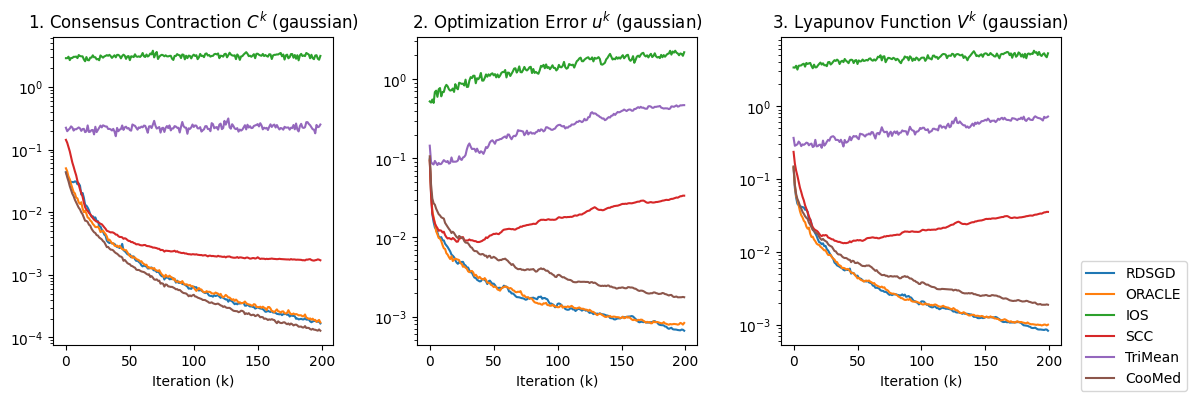

In [20]:
# Plot Lyapunov Function
fig, ax = plt.subplots(1,3,figsize=(13,4))
plot_cons_opt_lyap(df, ax)

fig.legend(loc='lower right')
fig.subplots_adjust(wspace=0.3)
fig.savefig(os.path.join(RUN_DIR,f'{config['graph_type']}_b{config['sys']['b']}_{atk}_{RUN_ID}_convergence.png'))
plt.show()

In [14]:
df2 = pd.DataFrame()
# min across nodes of test accuracy at final iteration
df2['lb_node_ta'] = df['min_test_acc'].groupby(['alg']).nth(-1).groupby(['alg']).first() 

# max across nodes of test accuracy at final iteration 
df2['ub_node_ta'] = df['max_test_acc'].groupby(['alg']).nth(-1).groupby(['alg']).first() 

# mean test accuracy taken over system
ser = df['test_acc'].groupby(['alg']).agg('mean')
ser['RDSGD'] = df.loc['RDSGD','test_acc_pi'].mean()
ser['ORACLE'] = df.loc['ORACLE','test_acc_pi'].mean()
df2['sys_mta'] = ser     

In [15]:
df2.sort_values('sys_mta', inplace=True, ascending=True)
display(df2)
df2.to_csv(os.path.join(RUN_DIR,f'{config['graph_type']}_b{config['sys']['b']}_{atk}_{RUN_ID}_final_ta.csv'))

,lb_node_ta,ub_node_ta,sys_mta
alg,,,
IOS,0.127359,0.503160,0.444788
TriMean,0.285541,0.678658,0.720727
SCC,0.827532,0.837056,0.841115
CooMed,0.850736,0.851861,0.847772
RDSGD,0.851342,0.854156,0.849838
ORACLE,0.852121,0.853939,0.850346


In [21]:
def graph_iter_node_ta_range(df2, ax):
    df2 = df2.sort_values('lb_node_ta')
    y_pos = np.arange(len(df2))
    bar_widths = df2['ub_node_ta'] - df2['lb_node_ta']
    ax.barh(y_pos, width=bar_widths, left=df2['lb_node_ta'],height=0.5, 
            color='skyblue', edgecolor='navy', alpha=0.7, label='LB-UB Range')
    
    ax.scatter(df2['sys_mta'], y_pos, color='red', marker='D', s=80,label='asymptotic TA', zorder=5)
    
    ref_line = df2['sys_mta'].mean()
    ax.axvline(x=ref_line, color='gray', linestyle='--', linewidth=1.5, label=f'Mean TA = {ref_line:.3f}')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df2.index)
    ax.set_xlabel('Test Accuracy')
    ax.set_xlabel('Value')
    ax.set_title(f'Inter-node TA Range and Asymptotic TA (T3:{atk})')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)

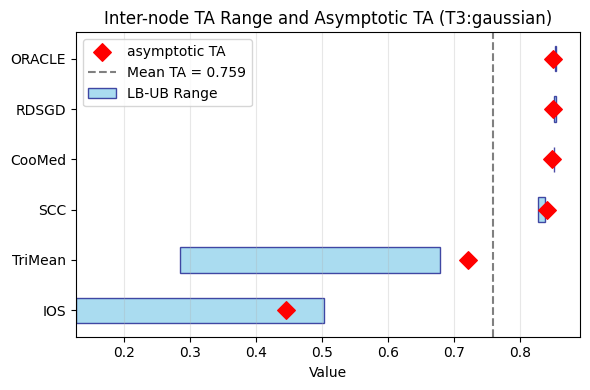

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
graph_iter_node_ta_range(df2, ax)

fig.savefig(os.path.join(RUN_DIR,f'{config['graph_type']}_b{config['sys']['b']}_{atk}_{RUN_ID}_ta_range_comparison.png'))
plt.tight_layout()
plt.show()

In [18]:
payload = copy.deepcopy(config)
del payload['graph_args']['MH_target_pi']
config.update(prelim_metrics)
with open(os.path.join(RUN_DIR,f'{payload['graph_type']}_b{payload['sys']['b']}_{atk}_{RUN_ID}_config.json'), 'w') as f:
    json.dump(payload, f, indent=2, default=convert)